# PART 1: FEATURE ENGINEERING

In [56]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Price_Dataset.csv')
df = df.sort_values('year').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Year range: {df['year'].min()}–{df['year'].max()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Columns: {list(df.columns)}")

Shape: (45, 15)
Year range: 1980–2024
Missing values: 0
Columns: ['year', 'pistachio_price_lb', 'pistachio_bearing_acres', 'pistachio_production_mt', 'almond_price_lb', 'iran_production_mt', 'SP500', 'CPI', 'wti_oil_price', 'electricity_price_kwh', 'fertilizer_ppi', 'us_disposable_income_bn', 'china_gdp_trillion_usd', 'fresno_rainfall_inches', 'usd_index']


In [57]:
log_cols = [
    'pistachio_price_lb', 'pistachio_production_mt', 'pistachio_bearing_acres',
    'iran_production_mt', 'almond_price_lb', 'SP500', 'CPI',
    'us_disposable_income_bn', 'china_gdp_trillion_usd',
    'wti_oil_price', 'fertilizer_ppi'
]

for col in log_cols:
    df[f'log_{col}'] = np.log(df[col])

print(f"Log transforms created: {len(log_cols)} variables")

Log transforms created: 11 variables


In [58]:
log_columns = [c for c in df.columns if c.startswith('log_')]
for col in log_columns:
    df[f'd_{col}'] = df[col].diff()

print(f"First differences created for {len(log_columns)} log variables")

First differences created for 11 log variables


In [59]:
lag_cols = [
    'log_pistachio_price_lb', 'log_pistachio_production_mt',
    'log_iran_production_mt', 'log_wti_oil_price',
    'log_fertilizer_ppi', 'fresno_rainfall_inches'
]

for col in lag_cols:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag2'] = df[col].shift(2)

print(f"1-year and 2-year lags created for {len(lag_cols)} variables")

1-year and 2-year lags created for 6 variables


In [60]:
roll_cols = [
    'log_pistachio_price_lb', 'log_pistachio_production_mt',
    'fresno_rainfall_inches', 'log_wti_oil_price'
]

for col in roll_cols:
    df[f'{col}_roll3_mean'] = df[col].rolling(window=3, min_periods=2).mean()
    df[f'{col}_roll3_std']  = df[col].rolling(window=3, min_periods=2).std()

print(f"Rolling 3-year mean and std created for {len(roll_cols)} variables")

Rolling 3-year mean and std created for 4 variables


In [61]:
# Interaction: combined input cost pressure
df['interact_oil_fert'] = df['log_wti_oil_price'] * df['log_fertilizer_ppi']

# Interaction: global supply pressure
df['interact_us_iran_prod'] = df['log_pistachio_production_mt'] * df['log_iran_production_mt']

# Interaction: weather-adjusted supply
df['interact_prod_rainfall'] = df['log_pistachio_production_mt'] * df['fresno_rainfall_inches']

# Biennial bearing dummy (1 = on-year, 0 = off-year)
df['production_change'] = df['pistachio_production_mt'].diff()
df['biennial_dummy'] = (df['production_change'] > 0).astype(int)

# Yield per acre (productivity measure)
df['yield_per_acre'] = df['pistachio_production_mt'] / df['pistachio_bearing_acres']
df['log_yield_per_acre'] = np.log(df['yield_per_acre'])

# Real price (inflation-adjusted)
base_cpi = df.loc[df['year'] == 1980, 'CPI'].values[0]
df['real_price'] = df['pistachio_price_lb'] / (df['CPI'] / base_cpi)
df['log_real_price'] = np.log(df['real_price'])

print(f"Engineered features complete. Total columns: {len(df.columns)}")
print(f"Interaction terms: oil×fert, us×iran prod, prod×rainfall")
print(f"Biennial dummy, yield per acre, real price created")

Engineered features complete. Total columns: 66
Interaction terms: oil×fert, us×iran prod, prod×rainfall
Biennial dummy, yield per acre, real price created


# Part 2 - RF and Gradient Boosting

In [62]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.2, 'grid.color': '#cccccc',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 130, 'font.size': 10,
})

print("Imports loaded.")

Imports loaded.


In [63]:
target = 'log_pistachio_price_lb'

feature_cols = [
    'log_pistachio_production_mt_lag1',   # supply: last year's harvest
    'log_wti_oil_price',                  # input cost: energy/transport
    'interact_oil_fert',                  # combined input cost pressure
    'log_us_disposable_income_bn',        # demand: purchasing power
    'log_almond_price_lb',                # substitute crop price
    'fresno_rainfall_inches',             # weather/drought
    'log_pistachio_price_lb_lag1',        # price persistence
    'biennial_dummy',                     # on/off harvest year
]

feature_labels = {
    'log_pistachio_production_mt_lag1': 'US Production (lag 1)',
    'log_wti_oil_price':                'Oil Price',
    'interact_oil_fert':                'Oil × Fertilizer',
    'log_us_disposable_income_bn':      'US Disposable Income',
    'log_almond_price_lb':              'Almond Price',
    'fresno_rainfall_inches':           'Fresno Rainfall',
    'log_pistachio_price_lb_lag1':      'Price (lag 1)',
    'biennial_dummy':                   'Biennial Dummy',
}

feature_cols = [c for c in feature_cols if c in df.columns]

print(f"Features selected: {len(feature_cols)}")
for f in feature_cols:
    print(f"  • {feature_labels.get(f, f)}")

model_df = df[['year', target] + feature_cols].dropna().reset_index(drop=True)
print(f"\nUsable observations: {len(model_df)} ({model_df['year'].min()}–{model_df['year'].max()})")

Features selected: 8
  • US Production (lag 1)
  • Oil Price
  • Oil × Fertilizer
  • US Disposable Income
  • Almond Price
  • Fresno Rainfall
  • Price (lag 1)
  • Biennial Dummy

Usable observations: 44 (1981–2024)


In [64]:
train_df = model_df[model_df['year'] < 2017].copy()
test_df  = model_df[model_df['year'] >= 2017].copy()

X_train = train_df[feature_cols]
y_train = train_df[target]
X_test  = test_df[feature_cols]
y_test  = test_df[target]

print(f"Train: {train_df['year'].min()}–{train_df['year'].max()} ({len(train_df)} obs)")
print(f"Test:  {test_df['year'].min()}–{test_df['year'].max()} ({len(test_df)} obs)")
print(f"Ratio: {len(feature_cols)} features / {len(train_df)} obs = 1:{len(train_df)//len(feature_cols)}")

Train: 1981–2016 (36 obs)
Test:  2017–2024 (8 obs)
Ratio: 8 features / 36 obs = 1:4


In [65]:
def compute_metrics(y_true_log, y_pred_log):
    """Returns dict of metrics in both log and $/lb space."""
    actual = np.exp(y_true_log)
    pred   = np.exp(y_pred_log)
    mse    = np.mean((actual - pred) ** 2)
    rmse   = np.sqrt(mse)
    mae    = np.mean(np.abs(actual - pred))
    mape   = np.mean(np.abs((actual - pred) / actual)) * 100
    r2     = r2_score(actual, pred)
    r2_log = r2_score(y_true_log, y_pred_log)
    return {
        'R²': r2, 'R² (log)': r2_log,
        'MSE': mse, 'RMSE': rmse,
        'MAE': mae, 'MAPE': mape,
    }

def print_metrics(m, label):
    print(f"\n  {label}:")
    print(f"    R²:   {m['R²']:.4f}")
    print(f"    MSE:  {m['MSE']:.4f}")
    print(f"    RMSE: {m['RMSE']:.4f}")
    print(f"    MAE:  ${m['MAE']:.4f}")
    print(f"    MAPE: {m['MAPE']:.2f}%")

print("Metrics function defined.")

Metrics function defined.


In [66]:
print("=" * 70)
print("RANDOM FOREST")
print("=" * 70)

tscv = TimeSeriesSplit(n_splits=3)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features=0.6,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred  = rf.predict(X_test)

rf_train_m = compute_metrics(y_train.values, rf_train_pred)
rf_test_m  = compute_metrics(y_test.values, rf_test_pred)

print_metrics(rf_train_m, 'Train (1981–2016)')
print_metrics(rf_test_m,  'Test  (2017–2024)')

cv = cross_val_score(rf, X_train, y_train, cv=tscv, scoring='r2')
print(f"\n  TS-CV R²: {[f'{s:.4f}' for s in cv]}  mean={cv.mean():.4f}")

RANDOM FOREST

  Train (1981–2016):
    R²:   0.7939
    MSE:  0.0977
    RMSE: 0.3125
    MAE:  $0.1891
    MAPE: 10.37%

  Test  (2017–2024):
    R²:   -0.0857
    MSE:  0.1688
    RMSE: 0.4108
    MAE:  $0.3936
    MAPE: 18.73%

  TS-CV R²: ['-6.1609', '-0.5030', '-3.0083']  mean=-3.2241


In [67]:
print("=" * 70)
print("GRADIENT BOOSTING")
print("=" * 70)

gbt = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    min_samples_split=5,
    min_samples_leaf=4,
    subsample=0.7,
    random_state=42,
)
gbt.fit(X_train, y_train)

gbt_train_pred = gbt.predict(X_train)
gbt_test_pred  = gbt.predict(X_test)

gbt_train_m = compute_metrics(y_train.values, gbt_train_pred)
gbt_test_m  = compute_metrics(y_test.values, gbt_test_pred)

print_metrics(gbt_train_m, 'Train (1981–2016)')
print_metrics(gbt_test_m,  'Test  (2017–2024)')

cv_gbt = cross_val_score(gbt, X_train, y_train, cv=tscv, scoring='r2')
print(f"\n  TS-CV R²: {[f'{s:.4f}' for s in cv_gbt]}  mean={cv_gbt.mean():.4f}")

GRADIENT BOOSTING

  Train (1981–2016):
    R²:   0.9914
    MSE:  0.0041
    RMSE: 0.0640
    MAE:  $0.0423
    MAPE: 2.68%

  Test  (2017–2024):
    R²:   -0.2351
    MSE:  0.1920
    RMSE: 0.4382
    MAE:  $0.3650
    MAPE: 18.58%

  TS-CV R²: ['-6.1624', '-0.6036', '-2.1156']  mean=-2.9606


In [68]:
print("=" * 70)
print("FEATURE IMPORTANCE — IMPURITY-BASED")
print("=" * 70)

rf_imp  = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
gbt_imp = pd.Series(gbt.feature_importances_, index=feature_cols).sort_values(ascending=False)

print(f"\n{'Rank':<6} {'Feature':<28} {'RF':>10} {'GBT':>10}")
print("-" * 58)
for i, feat in enumerate(rf_imp.index):
    label = feature_labels.get(feat, feat)
    print(f"{i+1:<6} {label:<28} {rf_imp[feat]:>10.4f} {gbt_imp[feat]:>10.4f}")


FEATURE IMPORTANCE — IMPURITY-BASED

Rank   Feature                              RF        GBT
----------------------------------------------------------
1      Oil × Fertilizer                 0.3183     0.1843
2      US Production (lag 1)            0.2621     0.3457
3      Oil Price                        0.1802     0.1058
4      US Disposable Income             0.1651     0.1305
5      Almond Price                     0.0358     0.1577
6      Price (lag 1)                    0.0210     0.0212
7      Biennial Dummy                   0.0093     0.0190
8      Fresno Rainfall                  0.0083     0.0357


In [69]:
print("=" * 70)
print("FEATURE IMPORTANCE — PERMUTATION-BASED (test set)")
print("=" * 70)

rf_perm  = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
gbt_perm = permutation_importance(gbt, X_test, y_test, n_repeats=30, random_state=42)

rf_perm_imp  = pd.Series(rf_perm.importances_mean, index=feature_cols).sort_values(ascending=False)
gbt_perm_imp = pd.Series(gbt_perm.importances_mean, index=feature_cols).sort_values(ascending=False)

print(f"\n{'Rank':<6} {'Feature':<28} {'RF':>10} {'± std':>8} {'GBT':>10} {'± std':>8}")
print("-" * 74)
for i, feat in enumerate(rf_perm_imp.index):
    label   = feature_labels.get(feat, feat)
    rf_val  = rf_perm_imp[feat]
    rf_std  = rf_perm.importances_std[feature_cols.index(feat)]
    gbt_val = gbt_perm_imp[feat]
    gbt_std = gbt_perm.importances_std[feature_cols.index(feat)]
    print(f"{i+1:<6} {label:<28} {rf_val:>10.4f} {rf_std:>8.4f} {gbt_val:>10.4f} {gbt_std:>8.4f}")

FEATURE IMPORTANCE — PERMUTATION-BASED (test set)

Rank   Feature                              RF    ± std        GBT    ± std
--------------------------------------------------------------------------
1      Oil × Fertilizer                 0.1100   0.1631     0.2264   0.1881
2      Fresno Rainfall                  0.0231   0.0143     0.1868   0.1604
3      Price (lag 1)                    0.0160   0.0105     0.1894   0.1135
4      Almond Price                     0.0040   0.0635     0.0499   0.2780
5      US Disposable Income            -0.0000   0.0000     0.0000   0.0000
6      US Production (lag 1)           -0.0000   0.0000     0.0000   0.0000
7      Biennial Dummy                  -0.0027   0.0021    -0.0003   0.0297
8      Oil Price                       -0.0516   0.0311    -0.0089   0.0094


Saved: feature_importance.png


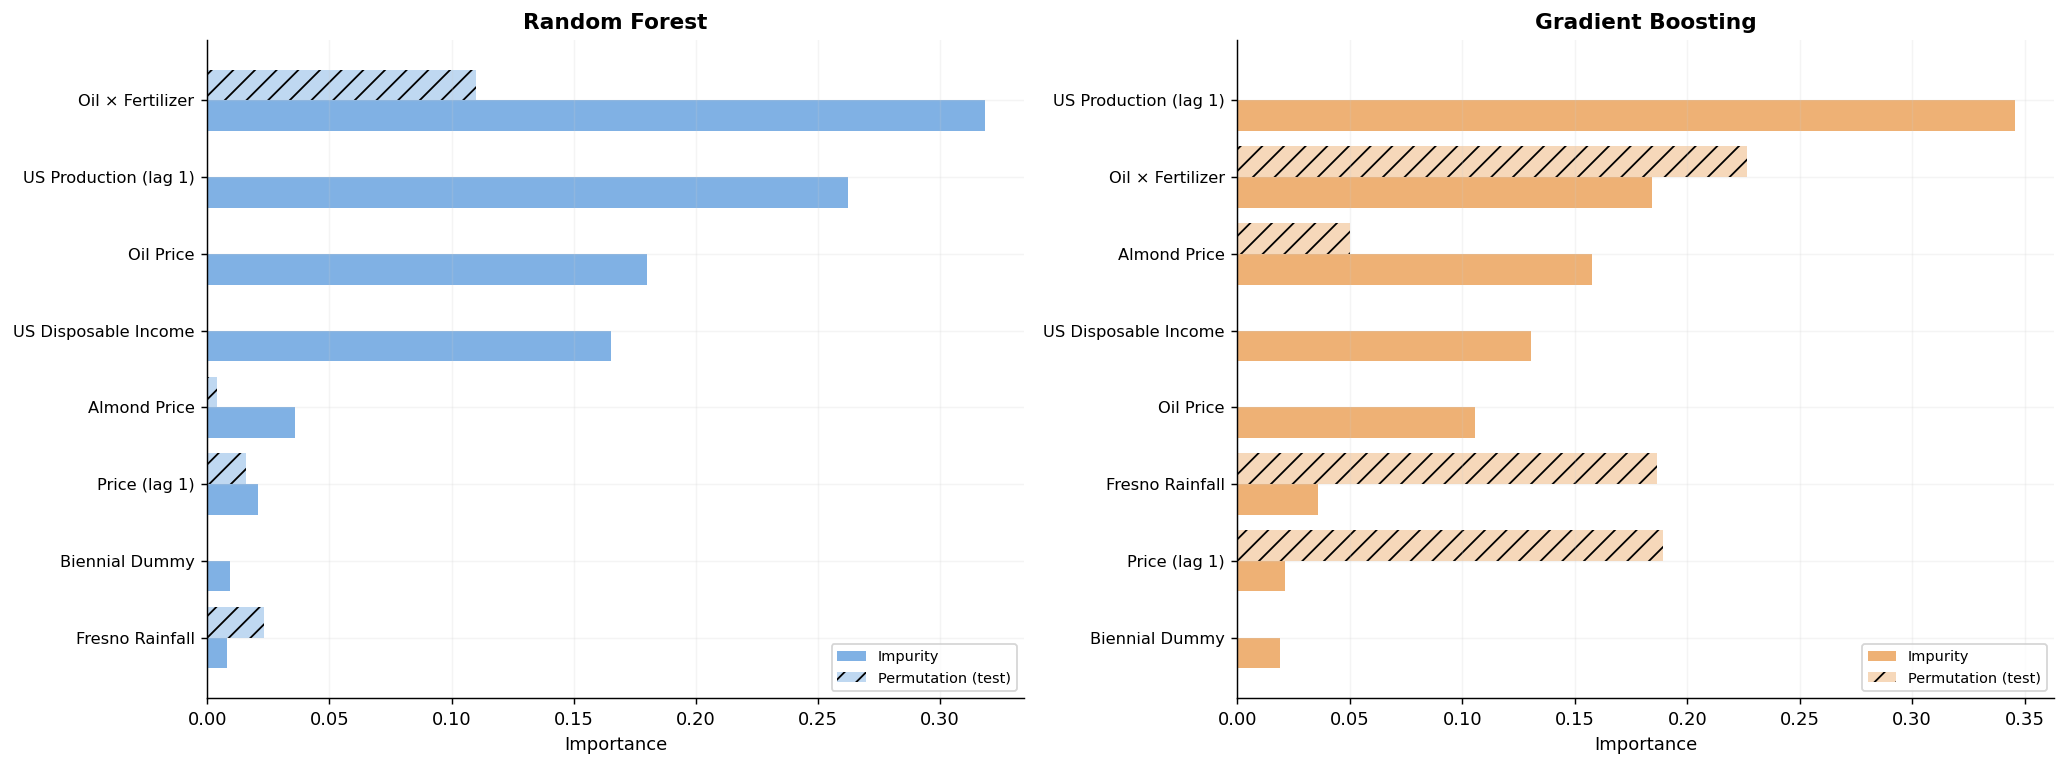

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, imp, perm_s, name, color in [
    (axes[0], rf_imp,  rf_perm_imp,  'Random Forest',     '#4a90d9'),
    (axes[1], gbt_imp, gbt_perm_imp, 'Gradient Boosting', '#e8913a'),
]:
    labels_sorted = [feature_labels.get(f, f) for f in imp.index]
    y_pos = np.arange(len(imp))

    ax.barh(y_pos, imp.values, height=0.4, align='edge',
            color=color, alpha=0.7, label='Impurity')
    perm_vals = [max(0, v) for v in perm_s.reindex(imp.index).values]
    ax.barh(y_pos - 0.4, perm_vals, height=0.4, align='edge',
            color=color, alpha=0.35, hatch='//', label='Permutation (test)')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels_sorted, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Importance')
    ax.set_title(f'{name}', fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
print("Saved: feature_importance.png")
plt.show()

Saved: predicted_vs_actual.png


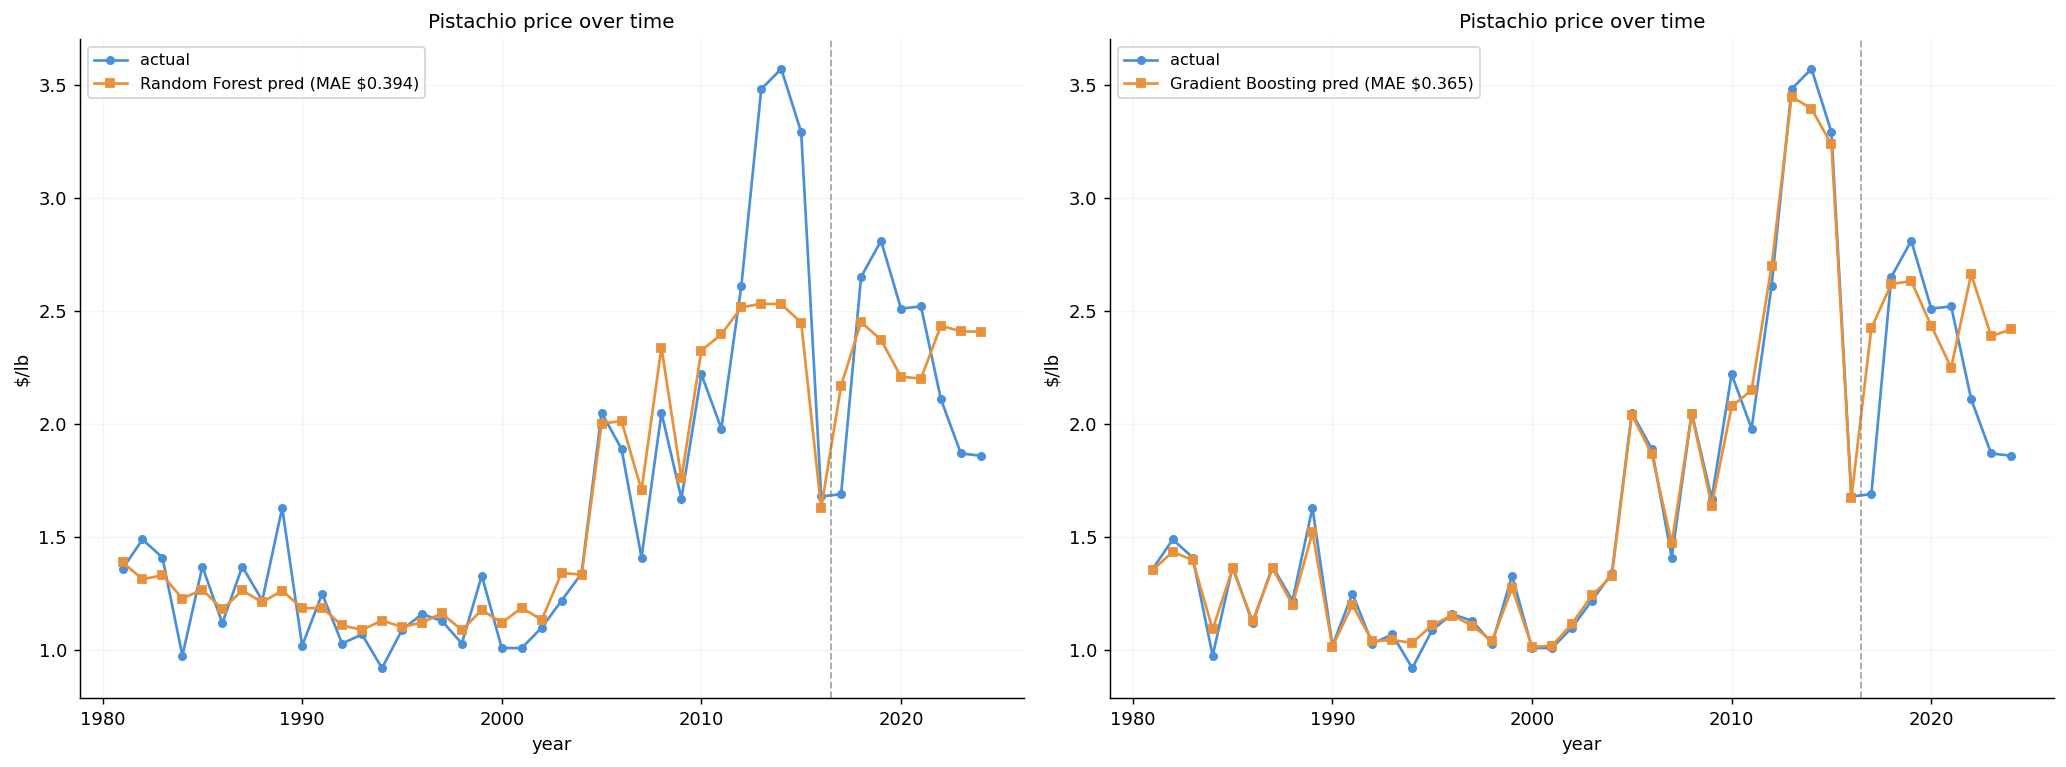

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name, train_pred, test_pred, test_m in [
    (axes[0], 'Random Forest',     rf_train_pred,  rf_test_pred,  rf_test_m),
    (axes[1], 'Gradient Boosting', gbt_train_pred, gbt_test_pred, gbt_test_m),
]:
    all_years  = pd.concat([train_df['year'], test_df['year']]).values
    all_actual = np.concatenate([np.exp(y_train), np.exp(y_test)])
    all_pred   = np.concatenate([np.exp(train_pred), np.exp(test_pred)])

    ax.plot(all_years, all_actual, 'o-', color='#4a90d9', markersize=4,
            lw=1.5, label='actual')
    ax.plot(all_years, all_pred, 's-', color='#e8913a', markersize=4,
            lw=1.5, label=f'{name} pred (MAE ${test_m["MAE"]:.3f})')

    ax.axvline(2016.5, color='gray', ls='--', lw=1, alpha=0.7)

    ax.set_xlabel('year')
    ax.set_ylabel('$/lb')
    ax.set_title('Pistachio price over time', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
print("Saved: predicted_vs_actual.png")
plt.show()

Saved: partial_dependence.png


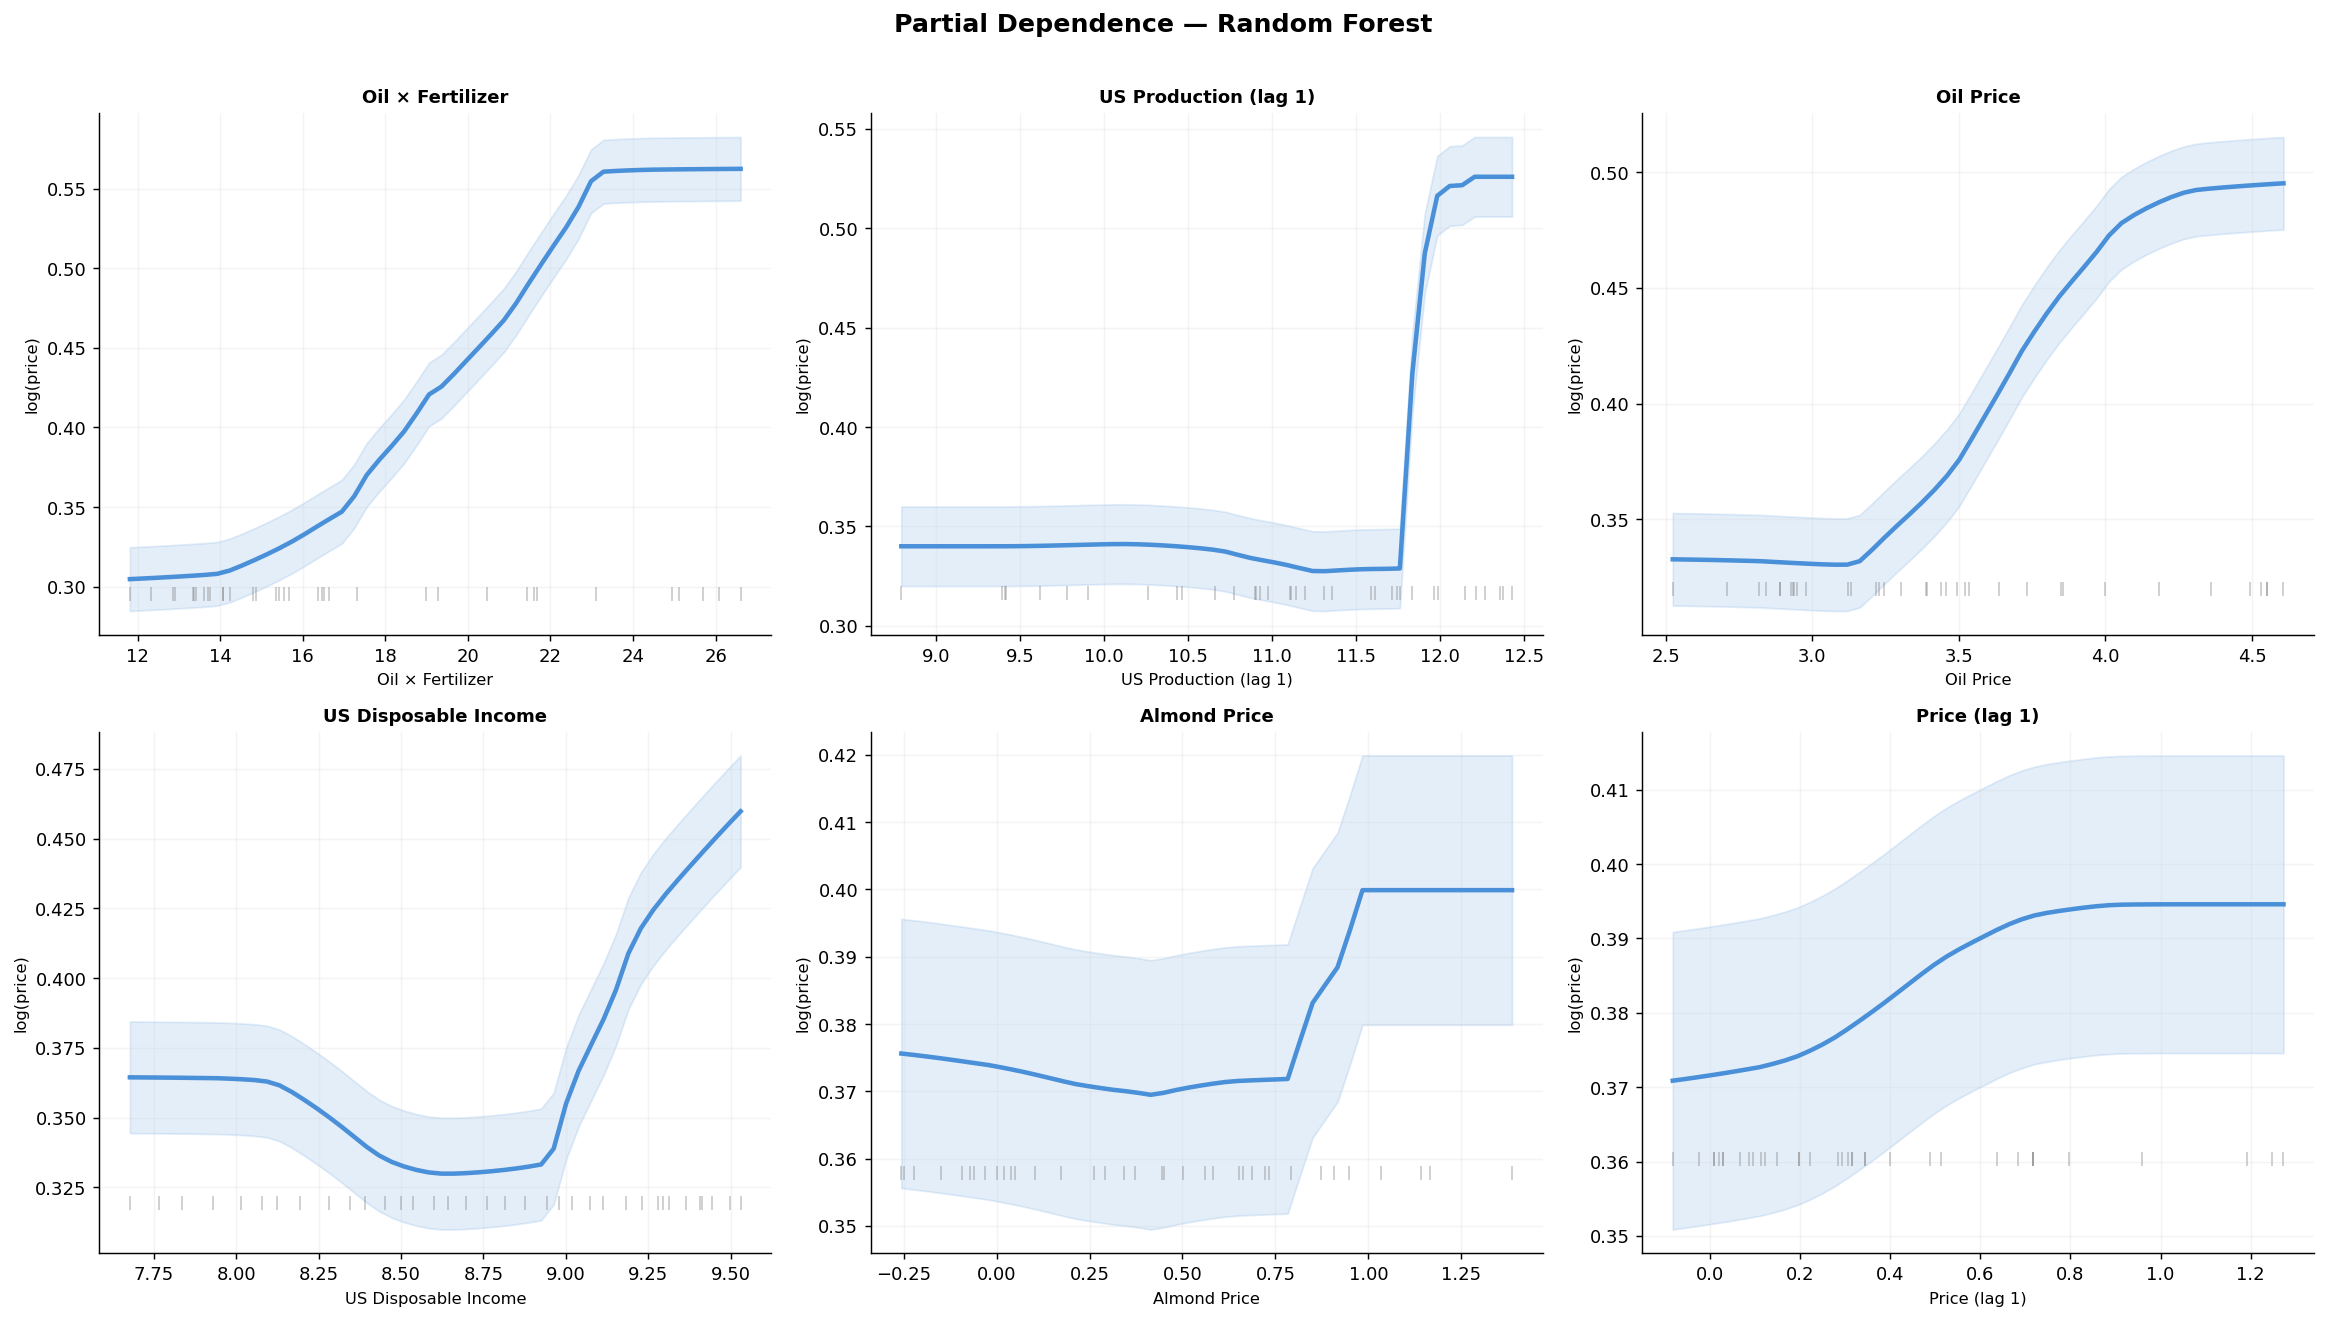

In [72]:
best_model = rf if rf_test_m['R²'] >= gbt_test_m['R²'] else gbt
best_name  = 'Random Forest' if rf_test_m['R²'] >= gbt_test_m['R²'] else 'Gradient Boosting'
best_imp   = rf_imp if best_name == 'Random Forest' else gbt_imp

top_6 = best_imp.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Partial Dependence — {best_name}', fontsize=14, fontweight='bold', y=1.01)

for idx, feat in enumerate(top_6):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]

    feat_values = np.linspace(X_train[feat].min(), X_train[feat].max(), 50)
    pd_values = []
    for val in feat_values:
        X_temp = X_train.copy()
        X_temp[feat] = val
        pd_values.append(best_model.predict(X_temp).mean())

    pd_arr = np.array(pd_values)
    smooth = lowess(pd_arr, feat_values, frac=0.3, return_sorted=True)

    ax.plot(smooth[:, 0], smooth[:, 1], color='#4a90d9', lw=2.5)
    ax.fill_between(smooth[:, 0], smooth[:, 1] - 0.02,
                    smooth[:, 1] + 0.02, alpha=0.15, color='#4a90d9')
    ax.plot(X_train[feat], [pd_arr.min() - 0.01] * len(X_train),
            '|', color='gray', alpha=0.4, markersize=8)

    label = feature_labels.get(feat, feat)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('log(price)', fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('partial_dependence.png', dpi=150, bbox_inches='tight')
print("Saved: partial_dependence.png")
plt.show()

Saved: residual_analysis.png


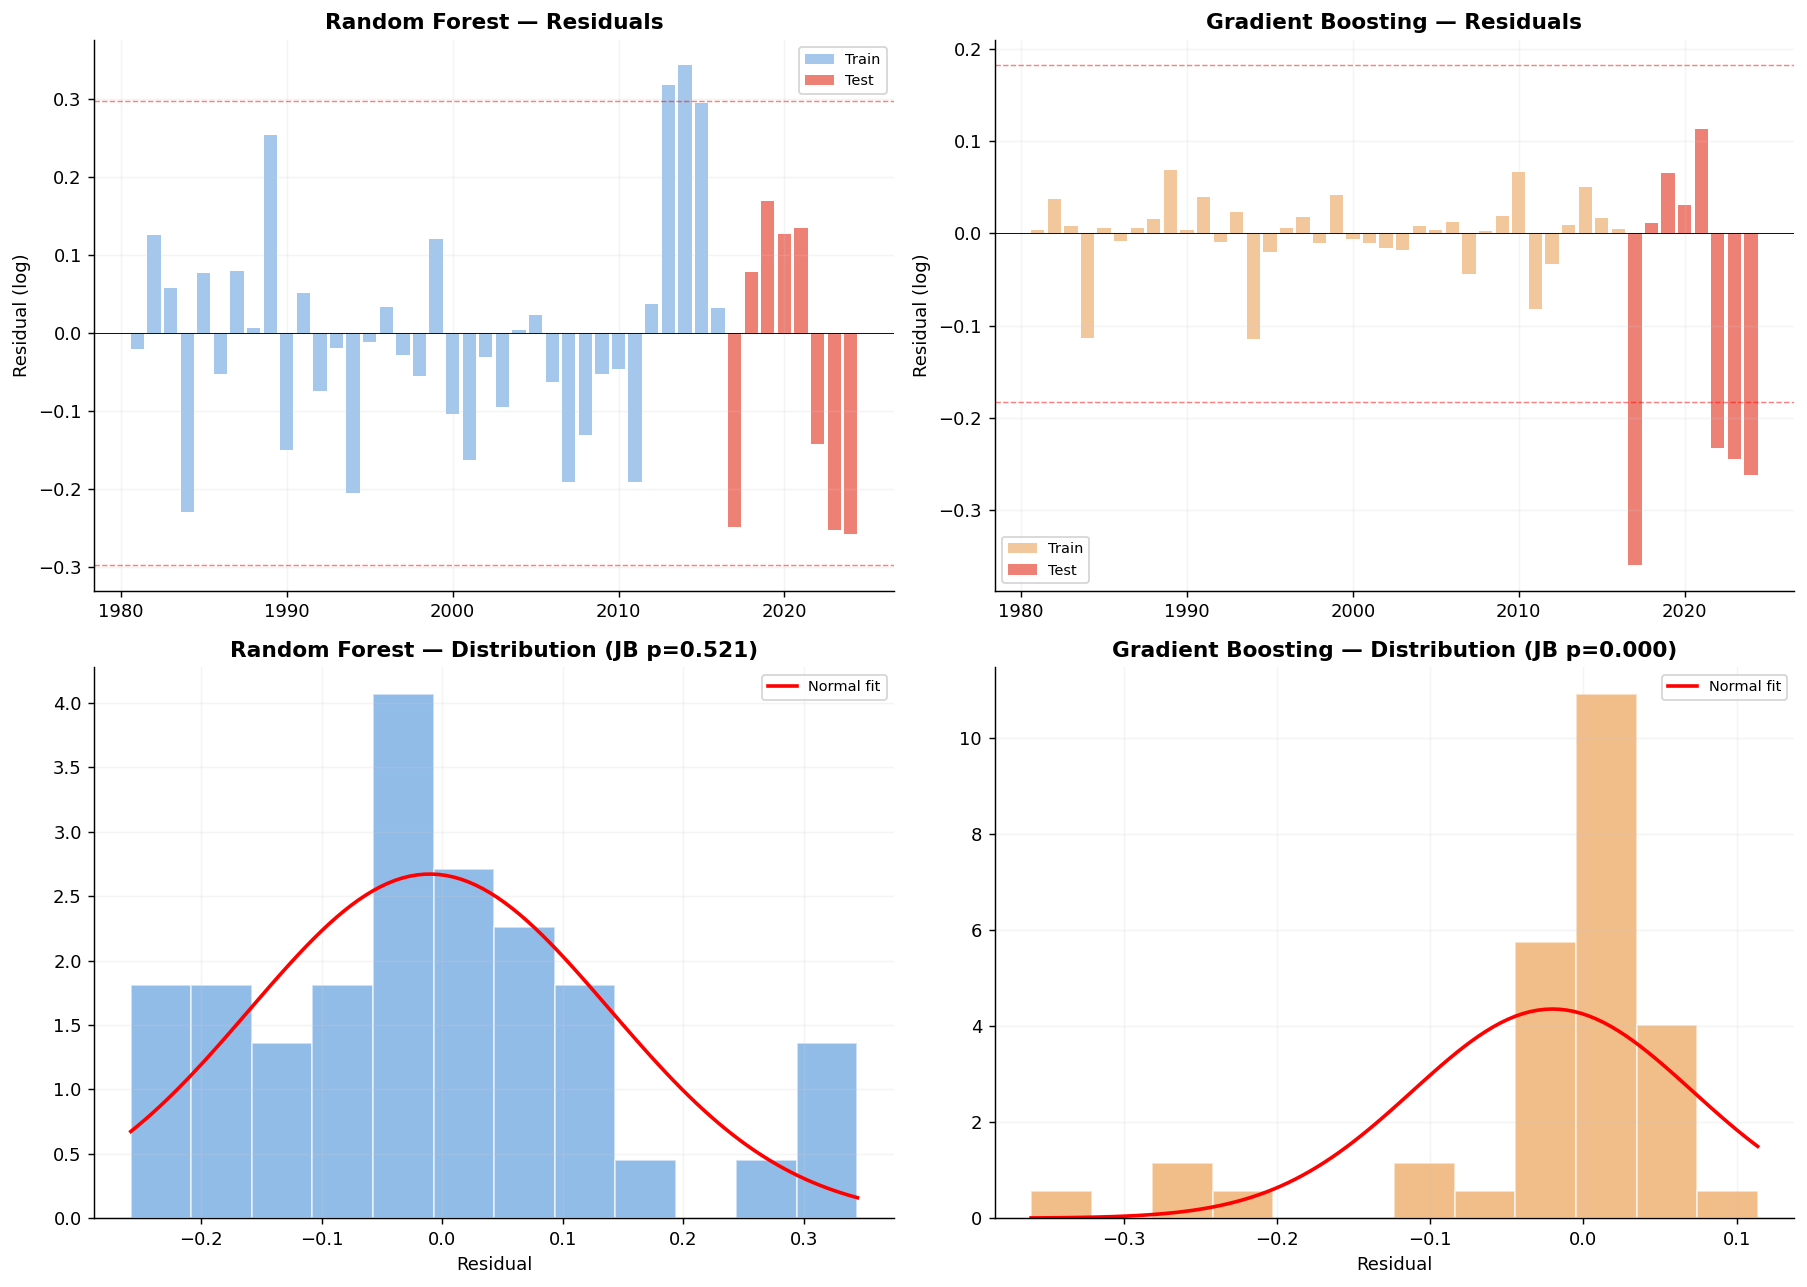

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, (name, train_pred, test_pred, color) in enumerate([
    ('Random Forest',     rf_train_pred,  rf_test_pred,  '#4a90d9'),
    ('Gradient Boosting', gbt_train_pred, gbt_test_pred, '#e8913a'),
]):
    # Residuals over time
    ax = axes[0, col_idx]
    train_resid = y_train.values - train_pred
    test_resid  = y_test.values - test_pred
    all_resid   = np.concatenate([train_resid, test_resid])

    ax.bar(train_df['year'], train_resid, color=color, alpha=0.5, width=0.8, label='Train')
    ax.bar(test_df['year'], test_resid, color='#e74c3c', alpha=0.7, width=0.8, label='Test')
    ax.axhline(0, color='black', lw=0.5)
    ax.axhline(2 * all_resid.std(), color='red', ls='--', lw=0.8, alpha=0.5)
    ax.axhline(-2 * all_resid.std(), color='red', ls='--', lw=0.8, alpha=0.5)
    ax.set_title(f'{name} — Residuals', fontweight='bold')
    ax.set_ylabel('Residual (log)')
    ax.legend(fontsize=8)

    # Residual histogram
    ax = axes[1, col_idx]
    ax.hist(all_resid, bins=12, density=True, color=color, alpha=0.6, edgecolor='white')
    x_norm = np.linspace(all_resid.min(), all_resid.max(), 100)
    ax.plot(x_norm, stats.norm.pdf(x_norm, all_resid.mean(), all_resid.std()),
            'r-', lw=2, label='Normal fit')
    jb_stat, jb_p = stats.jarque_bera(all_resid)
    ax.set_title(f'{name} — Distribution (JB p={jb_p:.3f})', fontweight='bold')
    ax.set_xlabel('Residual')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
print("Saved: residual_analysis.png")
plt.show()

In [74]:
print("=" * 70)
print("MODEL COMPARISON — Random Forest vs Gradient Boosting")
print("=" * 70)

print(f"\n{'Metric':<12} {'RF Train':>12} {'RF Test':>12} {'GBT Train':>12} {'GBT Test':>12}")
print("-" * 62)
for key in ['R²', 'MSE', 'RMSE', 'MAE', 'MAPE']:
    fmt = '.2f' if key == 'MAPE' else '.4f'
    suffix = '%' if key == 'MAPE' else ''
    prefix = '$' if key in ['MAE', 'RMSE'] else ''
    print(f"{key:<12} {prefix}{rf_train_m[key]:>11{fmt}}{suffix} "
          f"{prefix}{rf_test_m[key]:>11{fmt}}{suffix} "
          f"{prefix}{gbt_train_m[key]:>11{fmt}}{suffix} "
          f"{prefix}{gbt_test_m[key]:>11{fmt}}{suffix}")

print()
rf_gap  = rf_train_m['R²'] - rf_test_m['R²']
gbt_gap = gbt_train_m['R²'] - gbt_test_m['R²']
print(f"Overfitting gap (train R² - test R²):")
print(f"  RF:  {rf_gap:.4f}")
print(f"  GBT: {gbt_gap:.4f}")

print()
for metric in ['RMSE', 'MAE', 'MAPE']:
    winner = 'RF' if rf_test_m[metric] < gbt_test_m[metric] else 'GBT'
    print(f"  {metric}: {winner} wins ({min(rf_test_m[metric], gbt_test_m[metric]):.4f} "
          f"vs {max(rf_test_m[metric], gbt_test_m[metric]):.4f})")

MODEL COMPARISON — Random Forest vs Gradient Boosting

Metric           RF Train      RF Test    GBT Train     GBT Test
--------------------------------------------------------------
R²                0.7939     -0.0857      0.9914     -0.2351
MSE               0.0977      0.1688      0.0041      0.1920
RMSE         $     0.3125 $     0.4108 $     0.0640 $     0.4382
MAE          $     0.1891 $     0.3936 $     0.0423 $     0.3650
MAPE               10.37%       18.73%        2.68%       18.58%

Overfitting gap (train R² - test R²):
  RF:  0.8796
  GBT: 1.2265

  RMSE: RF wins (0.4108 vs 0.4382)
  MAE: GBT wins (0.3650 vs 0.3936)
  MAPE: GBT wins (18.5820 vs 18.7268)
